Please write your main code in this ipynb file. 

In [4]:
# import everything here
import pandas_datareader.data as web
import pandas as pd
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline
from scipy.linalg import solve_banded

## Part 1: Construct the Yield Curve 

### 1. Import dicrete treasury data from the Federal Reserve Economic Data (FRED) database.

In [ ]:
def get_treasury_yields_from_fred():
    # Define the duration (in years) and the corresponding FRED ID for each treasury yield
    yield_map = {
        1/12: "DGS1MO",
        3/12: "DGS3MO",
        6/12: "DGS6MO",
        1: "DGS1",
        2: "DGS2",
        3: "DGS3",
        5: "DGS5",
        7: "DGS7",
        10: "DGS10",
        20: "DGS20",
        30: "DGS30"
    }
    
    series_ids = list(yield_map.values())
    
    try:
        # Obtain the data for the last 5 days (make sure to get the latest and valid working day data)
        start = datetime(2026, 4, 1)
        df = web.DataReader(series_ids, 'fred', start)
        
        # Take the last non-empty row of data
        latest_data = df.dropna().iloc[-1]
        
        # Convert to DataFrame
        results = pd.DataFrame({
            'Maturity': yield_map.keys(),
            'Yield': latest_data.values
        }).sort_values('Maturity')
        
        return results
        
    except Exception as e:
        print(f"Failed to retrieve data: {e}")
        return None

# Execute retrieval
treasury_data = get_treasury_yields_from_fred()
print(treasury_data)

     Maturity  Yield
0    0.083333   3.71
1    0.250000   3.71
2    0.500000   3.73
3    1.000000   3.72
4    2.000000   3.84
5    3.000000   3.88
6    5.000000   3.99
7    7.000000   4.17
8   10.000000   4.35
9   20.000000   4.91
10  30.000000   4.91


### 2. Build the yield curve class with interpolation methods(piece wise and cubic spline), including the improved area-preserving quadratic spline (APQS) method.

In [12]:
class YieldCurve:
    def __init__(self, maturities, yields):
        idx = np.argsort(maturities)
        self.T = np.array(maturities)[idx]
        self.y = np.array(yields)[idx]
        self.m = len(self.T)
        
        # Step 1: yields -> discount factors
        self.df = np.exp(-self.y * self.T)
        
        # Step 2: discount factors -> piecewise constant forward rates
        # P(T_j) = exp(-integral_0^{T_j} f(t)dt)
        # For interval [T_{j-1}, T_j]: A[j] = -log(P(T_j)/P(T_{j-1})) / (T_j - T_{j-1})
        T_aug = np.insert(self.T, 0, 0.0)
        df_aug = np.insert(self.df, 0, 1.0)  # P(0) = 1
        delta = np.diff(T_aug)
        
        self.T_aug = T_aug
        self.delta = delta
        # A[j] = piecewise constant forward for interval j (0-indexed)
        self.A = -np.log(df_aug[1:] / df_aug[:-1]) / delta

    def get_interpolation(self, method='apqs'):
        if method == 'piecewise':
            # Return yield curve (convert forward back to yield for display)
            def pw_yield(t):
                t = np.atleast_1d(np.asarray(t, dtype=float))
                # Find which interval
                idx = np.searchsorted(self.T, t, side='left')
                idx = np.clip(idx, 0, self.m - 1)
                return self.y[idx]
            return pw_yield
        
        elif method == 'cubic':
            from scipy.interpolate import CubicSpline
            return CubicSpline(self.T, self.y, bc_type='natural')
        
        elif method == 'apqs':
            return self._build_apq_spline()

    def _build_apq_spline(self):
        T_aug = self.T_aug
        delta = self.delta
        A = self.A   # piecewise constant FORWARD rates, NOT yields
        n = self.m + 1

        ab = np.zeros((3, n))
        ab[1, :] = 1.0

        denom = delta[:-1] + delta[1:]
        w_lower = 0.5 * delta[1:] / denom
        w_upper = 0.5 * delta[:-1] / denom

        ab[2, 1:-1] = w_lower
        ab[0, 1:-1] = w_upper
        ab[0, 0] = 0.5
        ab[2, -1] = 0.5

        rhs = np.zeros(n)
        rhs[0] = 1.5 * A[0]
        rhs[-1] = 1.5 * A[-1]
        rhs[1:-1] = 1.5 * (delta[1:] * A[:-1] + delta[:-1] * A[1:]) / denom

        f_nodes = solve_banded((1, 1), ab, rhs)

        def forward_func(t):
            """Returns instantaneous forward rate f(t)"""
            t = np.atleast_1d(np.asarray(t, dtype=float))
            res = np.empty_like(t, dtype=float)

            left_mask  = t <= T_aug[0]
            right_mask = t >= T_aug[-1]
            mid_mask   = ~(left_mask | right_mask)

            res[left_mask]  = f_nodes[0]
            res[right_mask] = f_nodes[-1]

            j = np.searchsorted(T_aug[1:], t[mid_mask], side='left')
            j = np.clip(j, 0, self.m - 1)
            t_mid = t[mid_mask]
            xi = (t_mid - T_aug[j]) / delta[j]

            f0 = f_nodes[j]
            f1 = f_nodes[j + 1]
            aj = A[j]
            res[mid_mask] = (f0*(1-xi) + f1*xi
                             - 3*(f0 + f1 - 2*aj)*xi*(1-xi))
            return res

        def yield_func(t):
            """
            Convert forward rate back to yield for display:
            y(T) = (1/T) * integral_0^T f(s) ds
            Computed numerically per query point.
            """
            t = np.atleast_1d(np.asarray(t, dtype=float))
            res = np.empty_like(t, dtype=float)
            
            for i, ti in enumerate(t):
                if ti <= 0:
                    res[i] = f_nodes[0]
                else:
                    # Integrate f from 0 to ti using fine grid
                    s = np.linspace(0, ti, max(200, int(ti * 50)))
                    f_vals = forward_func(s)
                    res[i] = np.trapz(f_vals, s) / ti
            return res
        
        # Save the forward_func for use in get_forward_rate
        self._apqs_forward_func = forward_func
        return yield_func
    
    def get_forward_rate(self, t, method='apqs'):
        t = np.atleast_1d(np.asarray(t, dtype=float))

        if method == 'apqs':
            if not hasattr(self, '_apqs_forward_func'):
                self._build_apq_spline()
            return self._apqs_forward_func(t)

        elif method == 'cubic':
            cs = CubicSpline(self.T, self.y, bc_type='natural')
            return np.where(t <= 0, cs(0), cs(t) + t * cs(t, 1))

        elif method == 'piecewise':
            j = np.searchsorted(self.T_aug[1:], t, side='left')
            j = np.clip(j, 0, self.m - 1)
            return self.A[j]

        else:
            raise ValueError(f"Unknown method '{method}'. Choose from: 'apqs', 'cubic', 'piecewise'")


    def get_discount_factor(self, t, method='apqs'):
        """
        P(0,t) = exp(-∫_0^t f(s)ds)
        
        For piecewise, use the analytical formula (with no numerical errors and no need for loops)
        For apqs/cubic, use vectorized cumulative trapezoid
        """
        t = np.atleast_1d(np.asarray(t, dtype=float))

        if method == 'piecewise':
            # log P(0,t) = -sum_{j<j_end} A[j]*delta[j]  -  A[j_end]*(t - T_aug[j_end])
            #
            # First, calculate the cumulative log P value at each node for each interval.
            log_P_nodes = np.zeros(self.m + 1)
            log_P_nodes[1:] = -np.cumsum(self.A * self.delta)  # shape (m,)
            
            j = np.searchsorted(self.T_aug[1:], t, side='left')
            j = np.clip(j, 0, self.m - 1)
            
            # piecewise constant forward: log P(0,t) = log P at last node - A[j]*(t - T_aug[j])
            log_P = log_P_nodes[j] - self.A[j] * (t - self.T_aug[j])
            log_P[t <= 0] = 0.0
            return np.exp(log_P)

        else:
            # apqs / cubic: Calculate the integrals of all t values at once on the public fine grid.
            # Use cumulative trapezoid to avoid integrating each t separately
            t_max = np.max(t)
            n_grid = max(2000, int(t_max * 100))
            s = np.linspace(0, t_max, n_grid)          # public fine grid
            f_vals = self.get_forward_rate(s, method=method)
            
            # cumulative integral F(s) = ∫_0^s f(u)du
            from scipy.integrate import cumulative_trapezoid
            F = np.zeros(n_grid)
            F[1:] = cumulative_trapezoid(f_vals, s)    # shape (n_grid,)
            
            # For each query point t, interpolate F(t)
            F_interp = np.interp(t, s, F)
            result = np.exp(-F_interp)
            result[t <= 0] = 1.0
            return result


    def get_zero_rate(self, t, method='apqs'):
        """
        y(t) = -log(P(0,t)) / t
        use get_discount_factor
        """
        t = np.atleast_1d(np.asarray(t, dtype=float))
        P = self.get_discount_factor(t, method=method)
        
        result = np.empty_like(t, dtype=float)
        nonzero = t > 0
        result[nonzero] = -np.log(P[nonzero]) / t[nonzero]
        result[~nonzero] = self.get_forward_rate(np.array([1e-8]), method=method)[0]
        return result

### 3. Visualization of the curves with different interpolation methods(piece wise and cubic spline, area-preserving quadratic spline (APQS) method).

/var/folders/yx/rsrzkvxj3_b7jzdws5np_0mm0000gn/T/ipykernel_5836/349340581.py:106: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  res[i] = np.trapz(f_vals, s) / ti


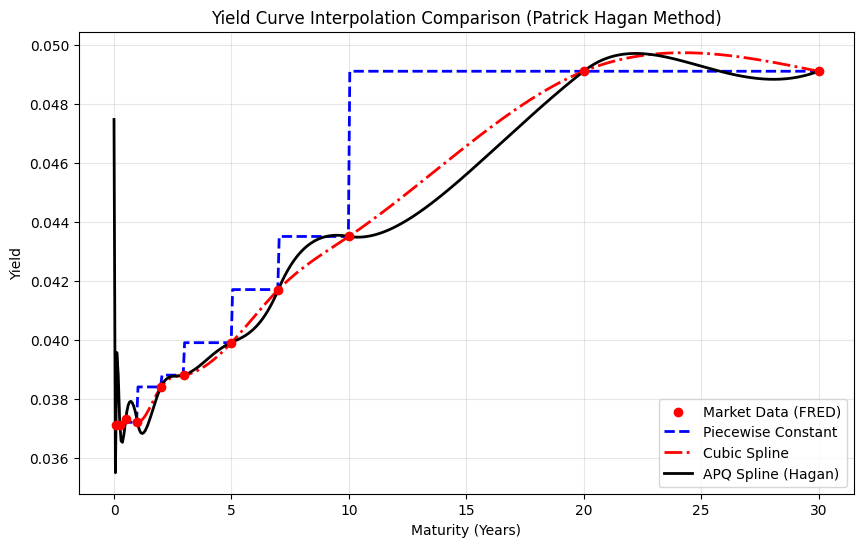

In [13]:
# Prepare Data (Assumes treasury_data from previous step)
# Convert yield to decimal for calculation (e.g., 4.5% -> 0.045)
maturities = treasury_data['Maturity'].values
yields = treasury_data['Yield'].values / 100.0

# Instantiate and Generate Curves
curve_builder = YieldCurve(maturities, yields)
t_range = np.linspace(0, 30, 500)

methods = {
    'Piecewise Constant': ('piecewise', 'blue', '--'),
    'Cubic Spline': ('cubic', 'red', '-.'),
    'APQ Spline (Hagan)': ('apqs', 'black', '-')
}

plt.figure(figsize=(10, 6))
plt.scatter(maturities, yields, color='red', label='Market Data (FRED)', zorder=5)

for label, (m, color, style) in methods.items():
    f_interp = curve_builder.get_interpolation(method=m)
    plt.plot(t_range, f_interp(t_range), label=label, color=color, linestyle=style, lw=2)

plt.title("Yield Curve Interpolation Comparison (Patrick Hagan Method)")
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Part 2 Calibrate and Simulate Interest Rate Paths

### Interface Documentation: Part 1 to Part 2

### 1. Initialize YieldCurve
curve = YieldCurve(maturities, yields)
#### method options: 'apqs' (recommended), 'cubic', 'piecewise'

### 2. Available interfaces from Part 2

#### Instantaneous forward rate f(0,t) — used to compute θ(t)
f = curve.get_forward_rate(t, method='apqs')

### Initial short rate r(0) — starting point for simulation
r0 = curve.get_forward_rate(np.array([1e-6]), method='apqs')[0]

### Discount factor P(0,T) — only needed if you are calibrating a and sigma from market data
P = curve.get_discount_factor(t, method='apqs')

### 3. Pass into your HullWhiteModel
hw = HullWhiteModel(curve, a=..., sigma=..., method='apqs')

In [14]:
class HullWhiteModel:
    def __init__(self, yield_curve, a: float, sigma: float, method: str = 'apqs'):
        """
        yield_curve: YieldCurve object from Part 2
        Initialize the Hull-White model with the given yield curve, mean reversion speed a, volatility sigma, and interpolation method.
        """
        self.curve = yield_curve
        self.a = a
        self.sigma = sigma
        self.method = method

    def theta(self, t):
        """
        TODO: Please implement the drift adjustment θ(t) to match the initial yield curve.
        Formula reference: θ(t) = ∂f(0,t)/∂t + a·f(0,t) + (σ²/2a)·(1 - e^{-2at})
        Hint: Need to numerically differentiate the forward rate f(0,t).
        """
        
        pass 
        

    def simulate(self, T: float, n_steps: int, n_paths: int, seed: int = None):
        """
        TODO: Please implement the Monte Carlo simulation of Hull-White short rate paths.
        Stochastic differential equation (SDE): dr(t) = [θ(t) - a·r(t)]dt + σ·dW(t)
        Hint:
        1. Use Euler-Maruyama discretization.
        2. The initial value r(0) can be obtained from the yield_curve as the instantaneous forward rate for very short maturities.
        """
        if seed is not None:
            np.random.seed(seed)
        
        dt = T / n_steps
        t_grid = np.linspace(0, T, n_steps + 1)
        
        
        
        
        return None # return rates and t_grid

For part 2, please also try other multifactor models other than HullWhiteModel as Choi suggested previoulsy

### Part 3 Model Nonlinear Prepayment Behavior under changing interest rate conditions